In [1]:
from functions import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation


In [2]:
file_list = [
    "data/PWS_NASA_Dataset111_rrf.faa",
    "data/PWS_NASA_Dataset111_u.faa",
    "data/PWS_NASA_Dataset111_v.faa",
    "data/PWS_NASA_Dataset111_w.faa"
]
print_pws_files_data(file_list)

Processing file: data/PWS_NASA_Dataset111_rrf.faa
Metadata:
  Title: Case #1-11:  DFW Accident Case, Wet Microburst, Rain and Hail
  Variable: RRF
  Dimensions (x, y, z): (161, 161, 41)
  Simulation Time (seconds): 660.0
  Origin (x, y, z) in meters: (-4000.0, -4000.0, 0.0)
  Resolution (dx, dy, dz) in meters: (50.0, 50.0, 50.0)

Sample Data:
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0.

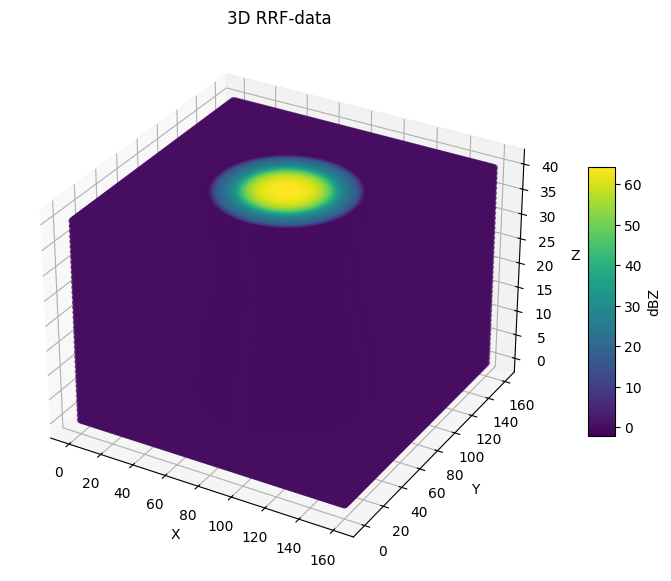

In [9]:
file_path = "data/PWS_NASA_Dataset111_rrf.faa"
data = read_pws_file(file_path)

u_data = data['data']  # ix, iy, iz
x_dim, y_dim, z_dim = u_data.shape

x = np.arange(x_dim)
y = np.arange(y_dim)
z = np.arange(z_dim)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()
U_flat = u_data.flatten()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_flat, Y_flat, Z_flat, c=U_flat, cmap='viridis')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('dBZ')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D RRF-data')
plt.show()

In [ ]:
u_data = read_pws_file("data/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("data/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("data/PWS_NASA_Dataset111_w.faa")

U = u_data['data']
V = v_data['data']
W = w_data['data']

xstart, ystart, zstart = u_data['origin_m']
dx, dy, dz = u_data['resolution_m']
ix, iy, iz = u_data['dimensions']

# Определение выбранной точки
x0, y0, z0 = xstart, ystart, zstart  #пример: начало координат

# сетка координат
i = np.arange(ix)
j = np.arange(iy)
k = np.arange(iz)
II, JJ, KK = np.meshgrid(i, j, k, indexing='ij')

x_coords = xstart + II * dx
y_coords = ystart + JJ * dy
z_coords = zstart + KK * dz

# Векторы от выбранной точки до каждой точки сетки
dx_rad = x_coords - x0
dy_rad = y_coords - y0
dz_rad = z_coords - z0

# Расстояние до выбранной точки и единичные векторы
distance = np.sqrt(dx_rad**2 + dy_rad**2 + dz_rad**2)
distance[distance == 0] = 1e-10  # защита от деления на ноль

unit_x = dx_rad / distance
unit_y = dy_rad / distance
unit_z = dz_rad / distance

# Расчет радиальной скорости
radial_velocity = U * unit_x + V * unit_y + W * unit_z

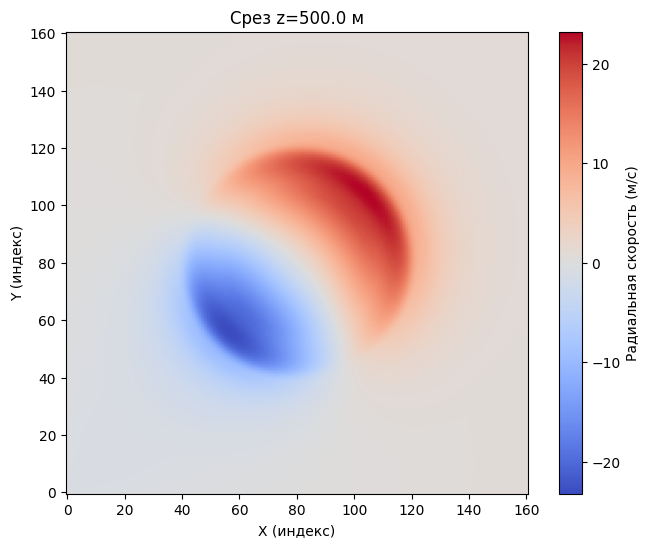

In [21]:
plt.figure(figsize=(8, 6))
plt.imshow(radial_velocity[:, :, 1], cmap='coolwarm', origin='lower')
plt.colorbar(label='Радиальная скорость (м/с)')
plt.title(f'Срез z={zstart + 10*dz} м')
plt.xlabel('X (индекс)')
plt.ylabel('Y (индекс)')
plt.show()